 ![](Coexistence-logo.png)

> ERC Starting Grant on COeXISTENCE between humans and machines in urban mobility.

## Milestone 1

<img src="img_mileston1.png" alt="Milestone 1 Image" width="500" height="400">

# Title: Comparison of different RL algorithms
## Name: Anastasia
### Date: March 4, 2024
---

### Decription

> In this notebook the case of 1 agent is examined. Within this context, there are two origins and two destinations and each agent is assigned to one of them. Each origin-destination pair has three available paths and each agent chooses between one of them.   

### Duration of Experiment Execution

| Algorithm     | Time (Minutes:Seconds) |
|---------------|------------------------|
| PPO           | 08:38                  |
| DQN           | 06:45                  |
| A2C           | 06:01                   |


## Experiment Objective

> The aim of this experiment is to examine the performance of various state-of-the-art RL algorithms in addressing our problem. Specifically, we seek to analyze the speed at which they execute a predetermined number of timesteps, their convergence rate, and the target value toward which they strive to converge.

## Expected Outcome

> According, to the PPO algorithm [paper](https://arxiv.org/abs/1707.06347), PPO has proven to show better results on the Atari domain compared to the A2C as far as the average reward per episode is concerned.

>In this paper, there are no comparisons between the DQN and the PPO algorithm. The only note is that DQN works well on game environments with discrete action spaces and it has not been demonstrated to perform well on continuous control benchmarks such as those in OpenAI Gym. So, making a comparison between PPO and DQN on a discrete action space environment will be interesting.

## Experiment Summary

### Network Architecture
- Csomor network


### Agents
| **Type**          | Altruistic          |
|-------------------|---------------------|
| **Number**        | 1                 |
| **New agents are created every** | 6 steps |


### Origin and Destination Details
| **Origin Count**      | 2                            |
|-----------------------|------------------------------|
| **Destination Count** | 2                            |
| **Origin Pairing**    | 279952229#0, 115604053       |
| **Destination Pairing**| -115602933#2, -441496282#1     |



### Reinforcement Learning Algorithm
- **Algorithm:** Proximal Policy Optimization (PPO)
  - **PPO Hyperparameters:**
    | Gamma | Learning Rate | Timesteps |
    |-------|---------------|-----------|
    | 0.9   | 1e-3          | 1000      |

    

### Hardware Utilized for Experiment Execution
| **Type of Machine** | Personal computer (or server) |
|----------------------|-------------------------------|
| **CPU**              | 12th Gen Intel(R) Core(TM) i7-1255U |
|                      | Cores: 10                   |
|                      | Sockets: 1                  |
|                      | Base Speed: 1.70 GHz        |
| **Memory**           | 16GB                          |
| **Disc (SSD)**       | 477 GB                        |
| **Operating System** | Windows 11                    |


### Imported libraries

In [1]:
import sys
sys.path.append('..')

from environment import TrafficEnvironment
from keychain import Keychain as kc
import os
from services import Trainer
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.env_checker import check_env
from pettingzoo.test import parallel_api_test
from gymnasium.spaces import Box, Discrete
from pettingzoo.classic import leduc_holdem_v4
from torch import nn
import gymnasium as gym
import supersuit as ss
from stable_baselines3 import PPO
from Sumo_controller import Sumo
from stable_baselines3 import A2C
from utilities import confirm_env_variable
from utilities import get_params

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

kc.PARAMS_PATH = '../params.json'

confirm_env_variable(kc.SUMO_HOME, append="tools")
params = get_params(kc.PARAMS_PATH)

[CONFIRMED] Environment variable exists: SUMO_HOME
[SUCCESS] Added module directory: C:\Program Files (x86)\Eclipse\Sumo\tools


> Change the paths of the experiments file.

In [2]:
#Define the number of paths used in this experiment
simulator_params = params[kc.SIMULATION_PARAMETERS]

for key, value in simulator_params.items():
    if key == "sumo_config_path":
        simulator_params[key] = "../Network_and_config/csomor1.sumocfg"
    if key =='edge_file_path':
        simulator_params[key] = "../Network_and_config/csomor1.edg.xml"
    if key == 'connection_file_path':
        simulator_params[key] = "../Network_and_config/csomor1.con.xml"
    if key == 'route_file_path':
        simulator_params[key] = "../Network_and_config/csomor1.rou.xml"
    if key == 'routes_xml_save_path':
        simulator_params[key] = "../Network_and_config/route.rou.xml"
    
params[kc.SIMULATION_PARAMETERS] = simulator_params

params

{'agent_generation_parameters': {'agents_data_path': 'agents_data.csv',
  'num_agents': 600,
  'agent_attributes': ['id',
   'origin',
   'destination',
   'start_time',
   'agent_type'],
  'simulation_timesteps': 3600,
  'origins': ['279952229#0', '115604053'],
  'destinations': ['-115602933#2', '-441496282#1'],
  'action_space_size': 3,
  'ONUR_COMMENT1': 'DO NOT PUT DEPENDENT VARS BELOW THIS LEVEL',
  'machine_agent_parameters': {'min_alpha': 0.1,
   'max_alpha': 0.6,
   'min_epsilon': 0.9,
   'max_epsilon': 1.0,
   'min_eps_decay': 0.99,
   'max_eps_decay': 0.99999,
   'gamma': 0.95},
  'human_agent_parameters': {'beta': -0.2, 'alpha': 0.2}},
 'environment_parameters': {'ONUR_COMMENT2': 'nothing for now'},
 'simulation_parameters': {'sumo_type': 'sumo',
  'sumo_config_path': '../Network_and_config/csomor1.sumocfg',
  'connection_file_path': '../Network_and_config/csomor1.con.xml',
  'edge_file_path': '../Network_and_config/csomor1.edg.xml',
  'route_file_path': '../Network_and_conf

## Custon Environment Creation 

### Instatiate Traci

In [3]:
Sumo_sim=Sumo(params)
Sumo_sim.Sumo_start()

###  Initialization of the TrafficEnvironment 

- **Network**: initialize network, create demand, create paths, calculate free flow travel times.

- **Learning**: initialize observation and action space.

### Configure Parameters in the Parameters Dictionary

In [4]:
number_of_paths = 3
origins = ["279952229#0", "115604053"]
destinations = ["-115602933#2", "-441496282#1"]
num_agents = 1

In [5]:
#Define the number of paths used in this experiment
simulator_params = params[kc.SIMULATION_PARAMETERS]

for key, value in simulator_params.items():
    if key == "number_of_paths":
        simulator_params[key] = number_of_paths
    if key =='origins':
        simulator_params[key] = origins
    if key == 'destinations':
        simulator_params[key] = destinations

params[kc.SIMULATION_PARAMETERS] = simulator_params

In [6]:
agent_generation_params = params[kc.AGENTS_GENERATION_PARAMETERS]

for key, value in agent_generation_params.items():
    if key == "num_agents":
        agent_generation_params[key] = num_agents

params[kc.AGENTS_GENERATION_PARAMETERS] = agent_generation_params

#### Environment Creation

In [7]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated 4 routes
[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Simulator is ready to simulate!
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [1.0603441376550622, 3.4148259303721487, 2.0871748699479795], (0, 1): [0.7787715086034414, 0.7676270508203282, 1.6727891156462587], (1, 0): [0.6873687704023294, 0.8676979676581997, 0.9195730415996491], (1, 1): [1.9843075459125334, 2.052040701089651, 1.9566764934915652]}

[SUCCESS] Free flow times calculated!

Agent 0 has origin 0 and destination 1.




### Parallel API Test

> To make sure our custom environment is consistent with the API, we have the api_test, more information [here](https://pettingzoo.farama.org/content/environment_tests/).

In [4]:
parallel_api_test(env, num_cycles=1_000_000)

Passed Parallel API test


### Stable-baselines3

> The reset function returns dictionaries containing observations and info for each agent.

In [5]:
env.reset(seed=None)

({'1': array([0.63608727]),
  '2': array([0.6014656]),
  '3': array([0.66086746]),
  '4': array([0.28320446]),
  '5': array([0.05366405]),
  '6': array([0.57891501]),
  '7': array([0.97822048]),
  '8': array([0.19271851]),
  '9': array([0.95859309]),
  '10': array([0.65355656]),
  '11': array([0.80694951]),
  '12': array([0.37983344]),
  '13': array([0.50315053]),
  '14': array([0.19529737]),
  '15': array([0.74806893]),
  '16': array([0.42322837]),
  '17': array([0.96569553]),
  '18': array([0.2341987]),
  '19': array([0.08605481]),
  '20': array([0.13516214]),
  '21': array([0.92958187]),
  '22': array([0.21579453]),
  '23': array([0.79360388]),
  '24': array([0.32234773]),
  '25': array([0.12841086]),
  '26': array([0.39707808]),
  '27': array([0.5046517]),
  '28': array([0.03054584]),
  '29': array([0.04824146]),
  '30': array([0.55028593]),
  '31': array([0.0167724]),
  '32': array([0.13331167]),
  '33': array([0.68853265]),
  '34': array([0.36897862]),
  '35': array([0.05226961])

> Returns a gym vector environment where each "environment" in the vector represents one agent.

In [8]:
env = ss.pettingzoo_env_to_vec_env_v1(env)

> The concat_vec_envs_v1 function takes in a vector environment. Creates a new vector environment with num_vec_envs copies of that vector environment concatenated together and runs them on num_cpus cpus as balanced as possible between cpus. num_cpus=0 or num_cpus=1 means to create 0 new threads, i.e. run the process in an efficient single threaded manner. A use case for this function is given below. If the base class of the resulting vector environment matters as it does for stable baselines, you can use the base_class parameter to switch between "gym" base class and "stable_baselines3"'s base class. Note that both have identical functionality

In [9]:
env = ss.concat_vec_envs_v1(env, 1, num_cpus=0, base_class="stable_baselines3")

# PPO

In [10]:
tuned_params = {
        "gamma": 0.9,
        "learning_rate": 1e-3,
    }

model = PPO(
    "MlpPolicy",
    env,
    verbose = 1,
    n_steps = 10,
    batch_size=10,
    device = "cuda",
    **tuned_params
)

Using cpu device


In [11]:
model.learn(total_timesteps=1000)

---------------------------
| time/              |    |
|    fps             | 2  |
|    iterations      | 1  |
|    time_elapsed    | 4  |
|    total_timesteps | 10 |
---------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 2            |
|    iterations           | 2            |
|    time_elapsed         | 9            |
|    total_timesteps      | 20           |
| train/                  |              |
|    approx_kl            | 0.0029759288 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.1         |
|    explained_variance   | 0.000836     |
|    learning_rate        | 0.001        |
|    loss                 | 1.31         |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0293      |
|    value_loss           | 3.52         |
------------------------------------------
------------------------------

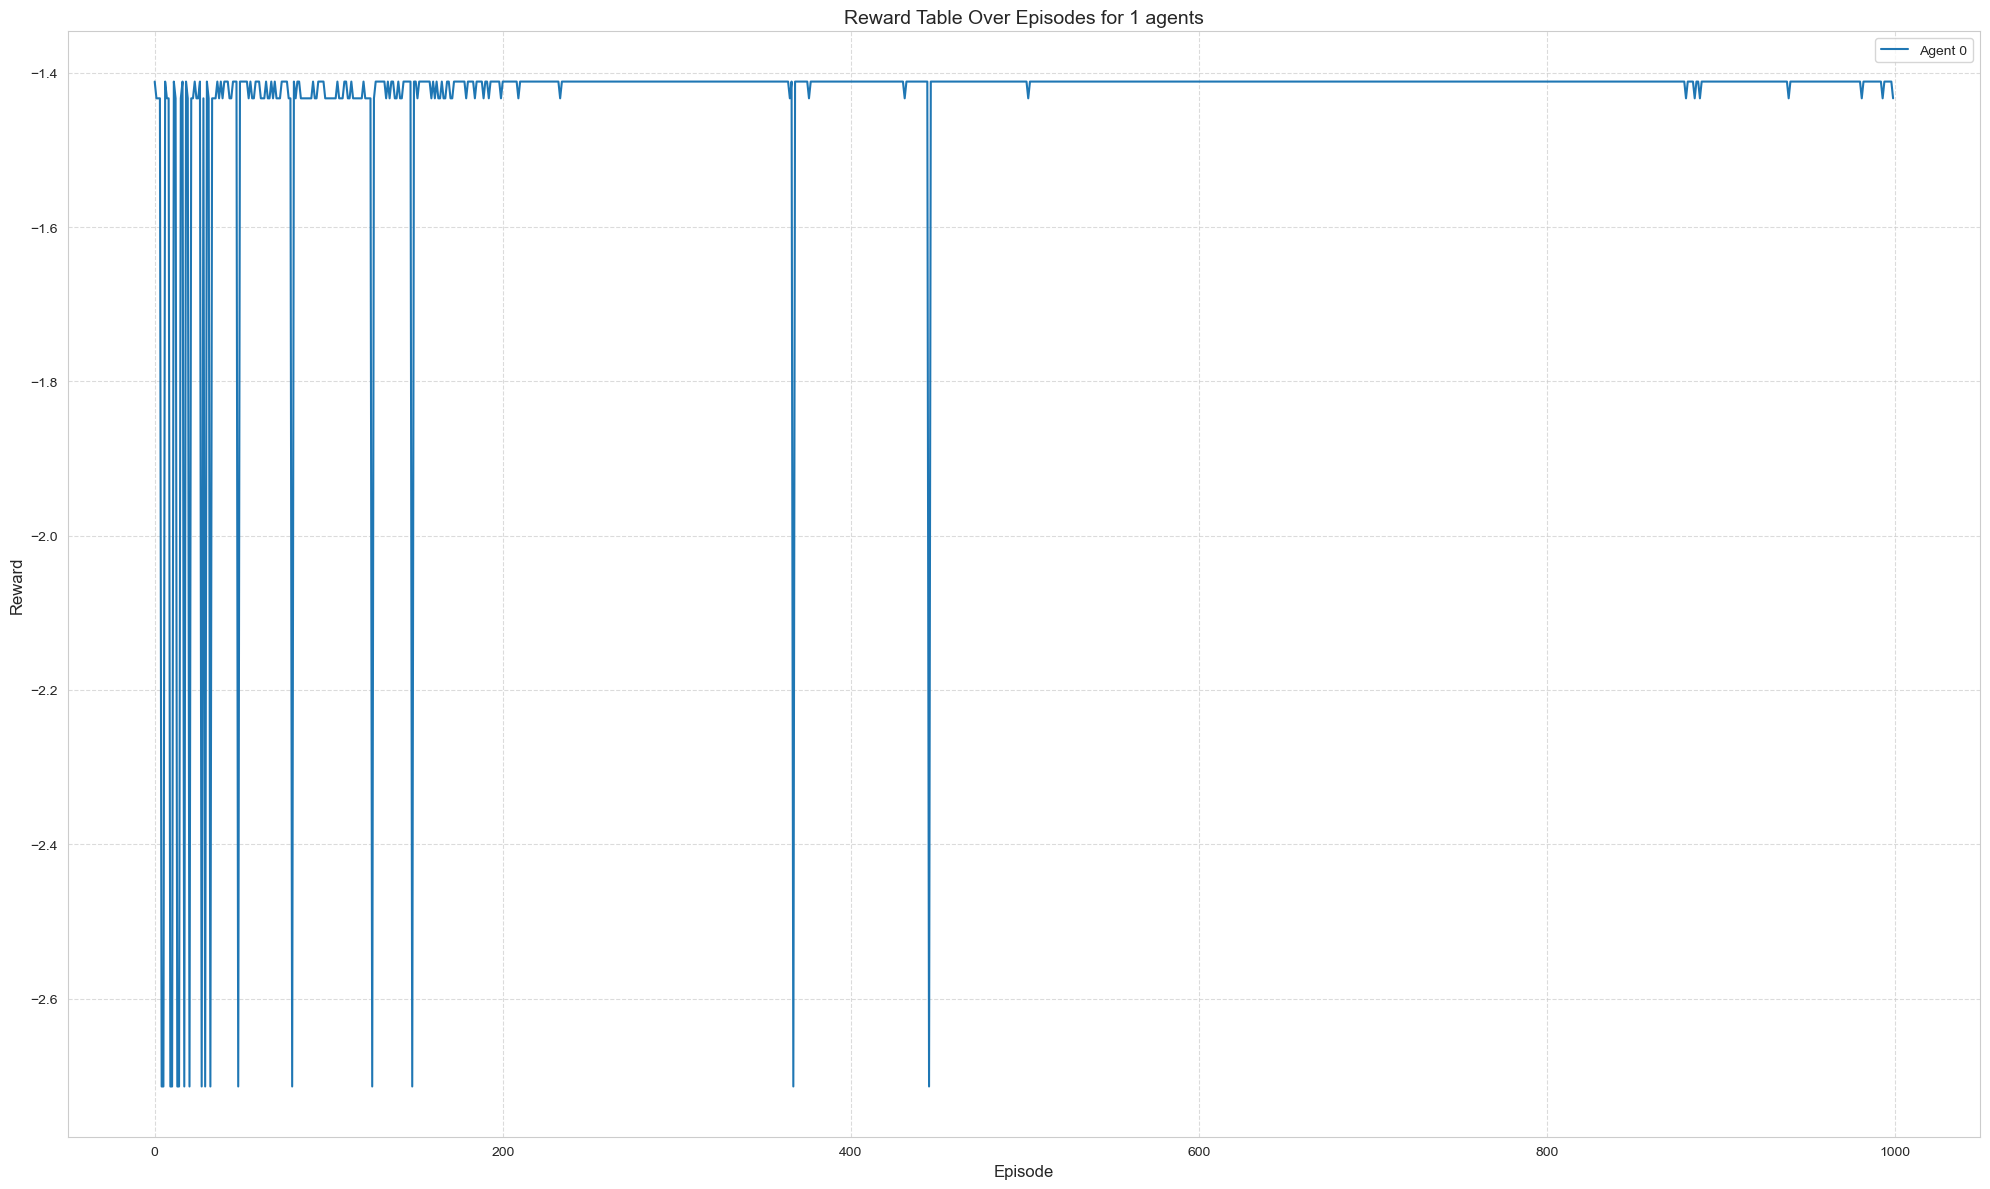

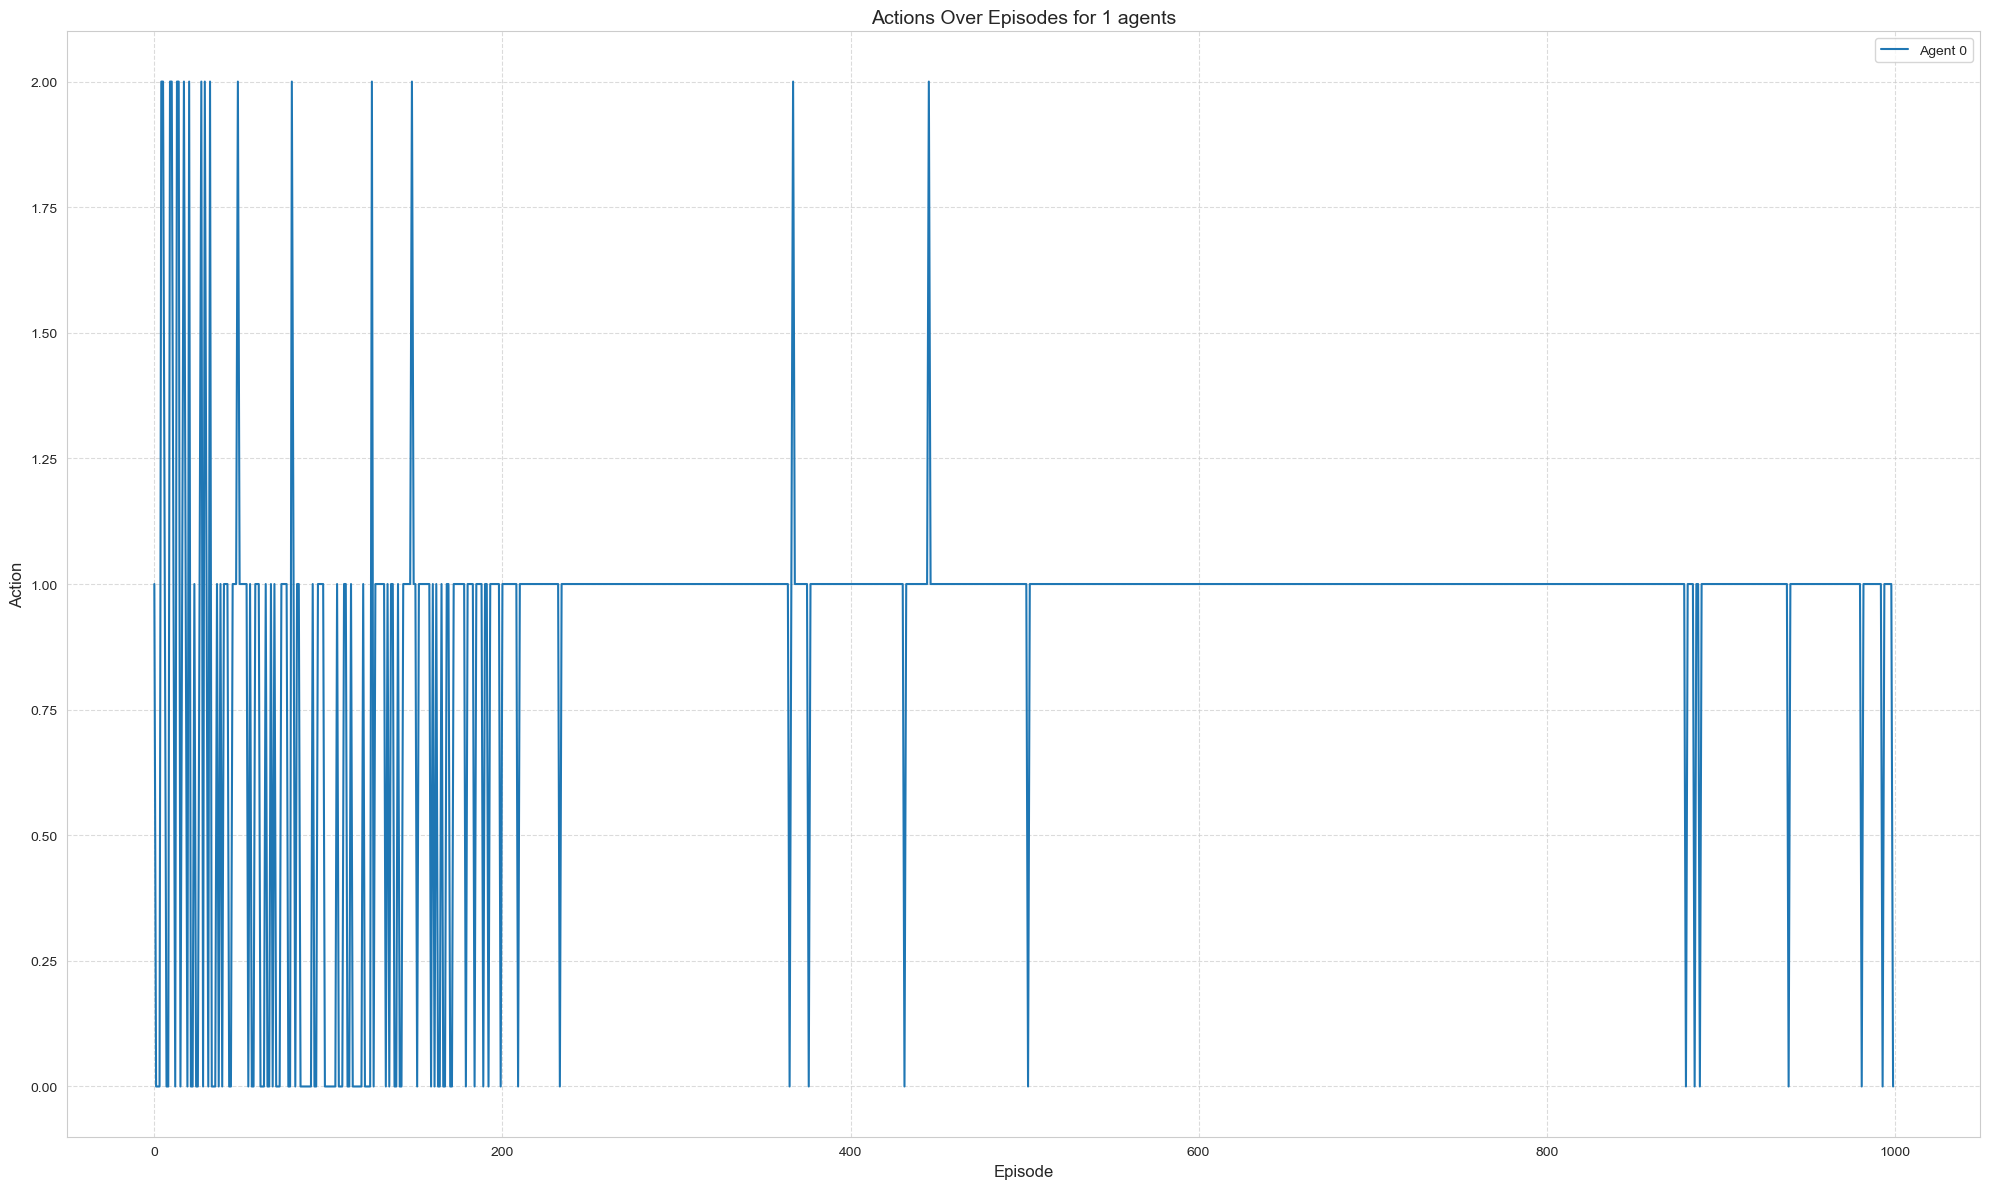

In [12]:
env.close()

# DQN

In [19]:
model = DQN(
        env=env,
        policy="MlpPolicy",
        learning_rate=0.001,
        train_freq=1,
        target_update_interval=500,
        exploration_initial_eps=0.05,
        exploration_final_eps=0,
        verbose=1,
)

Using cpu device


In [20]:
model.learn(total_timesteps=1000)

----------------------------------
| rollout/            |          |
|    exploration_rate | 0.048    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 2        |
|    time_elapsed     | 1        |
|    total_timesteps  | 4        |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.046    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 2        |
|    time_elapsed     | 3        |
|    total_timesteps  | 8        |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.044    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 2        |
|    time_elapsed     | 4        |
|    total_timesteps  | 12       |
----------------------------------
----------------------------------
| rollout/          

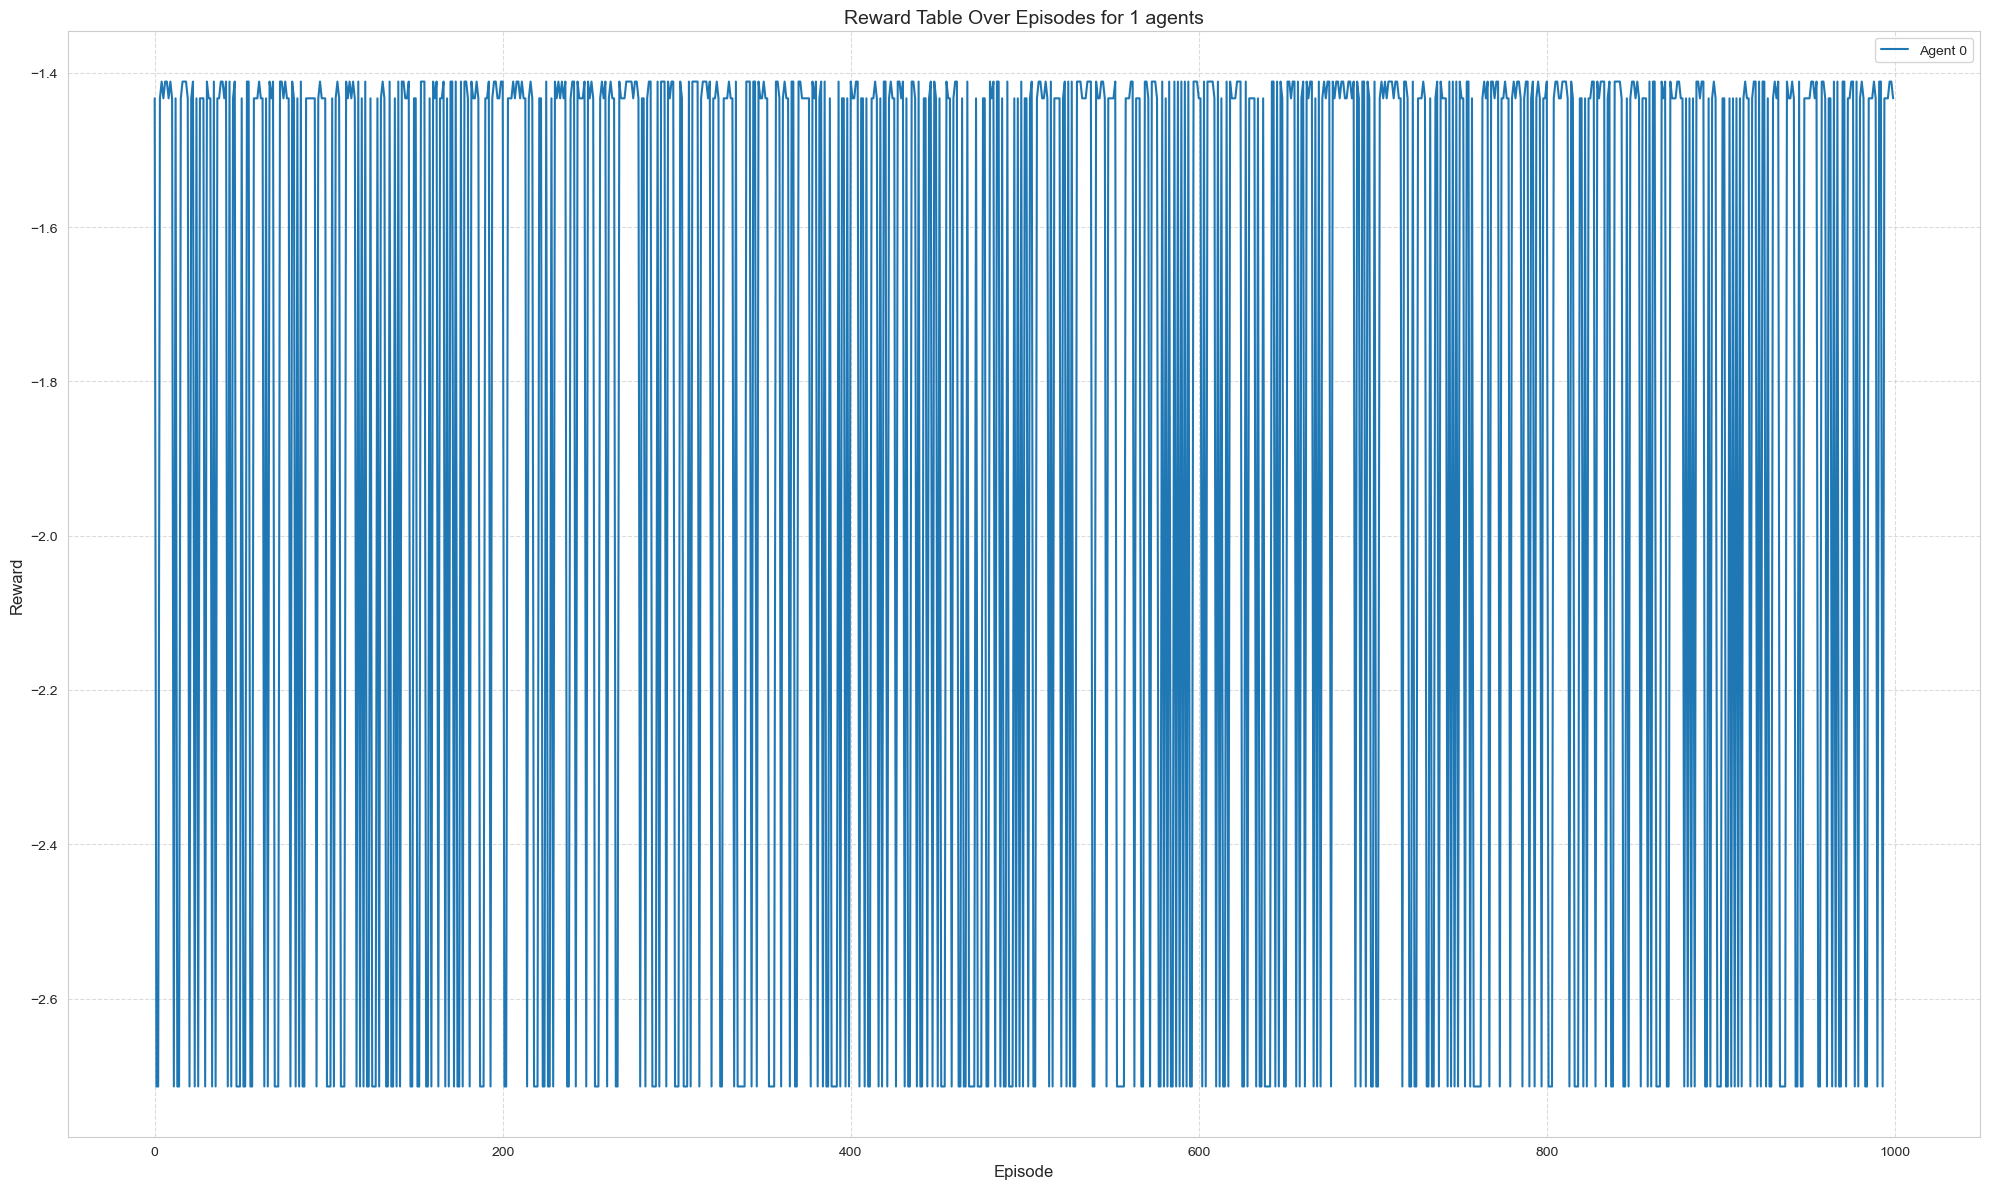

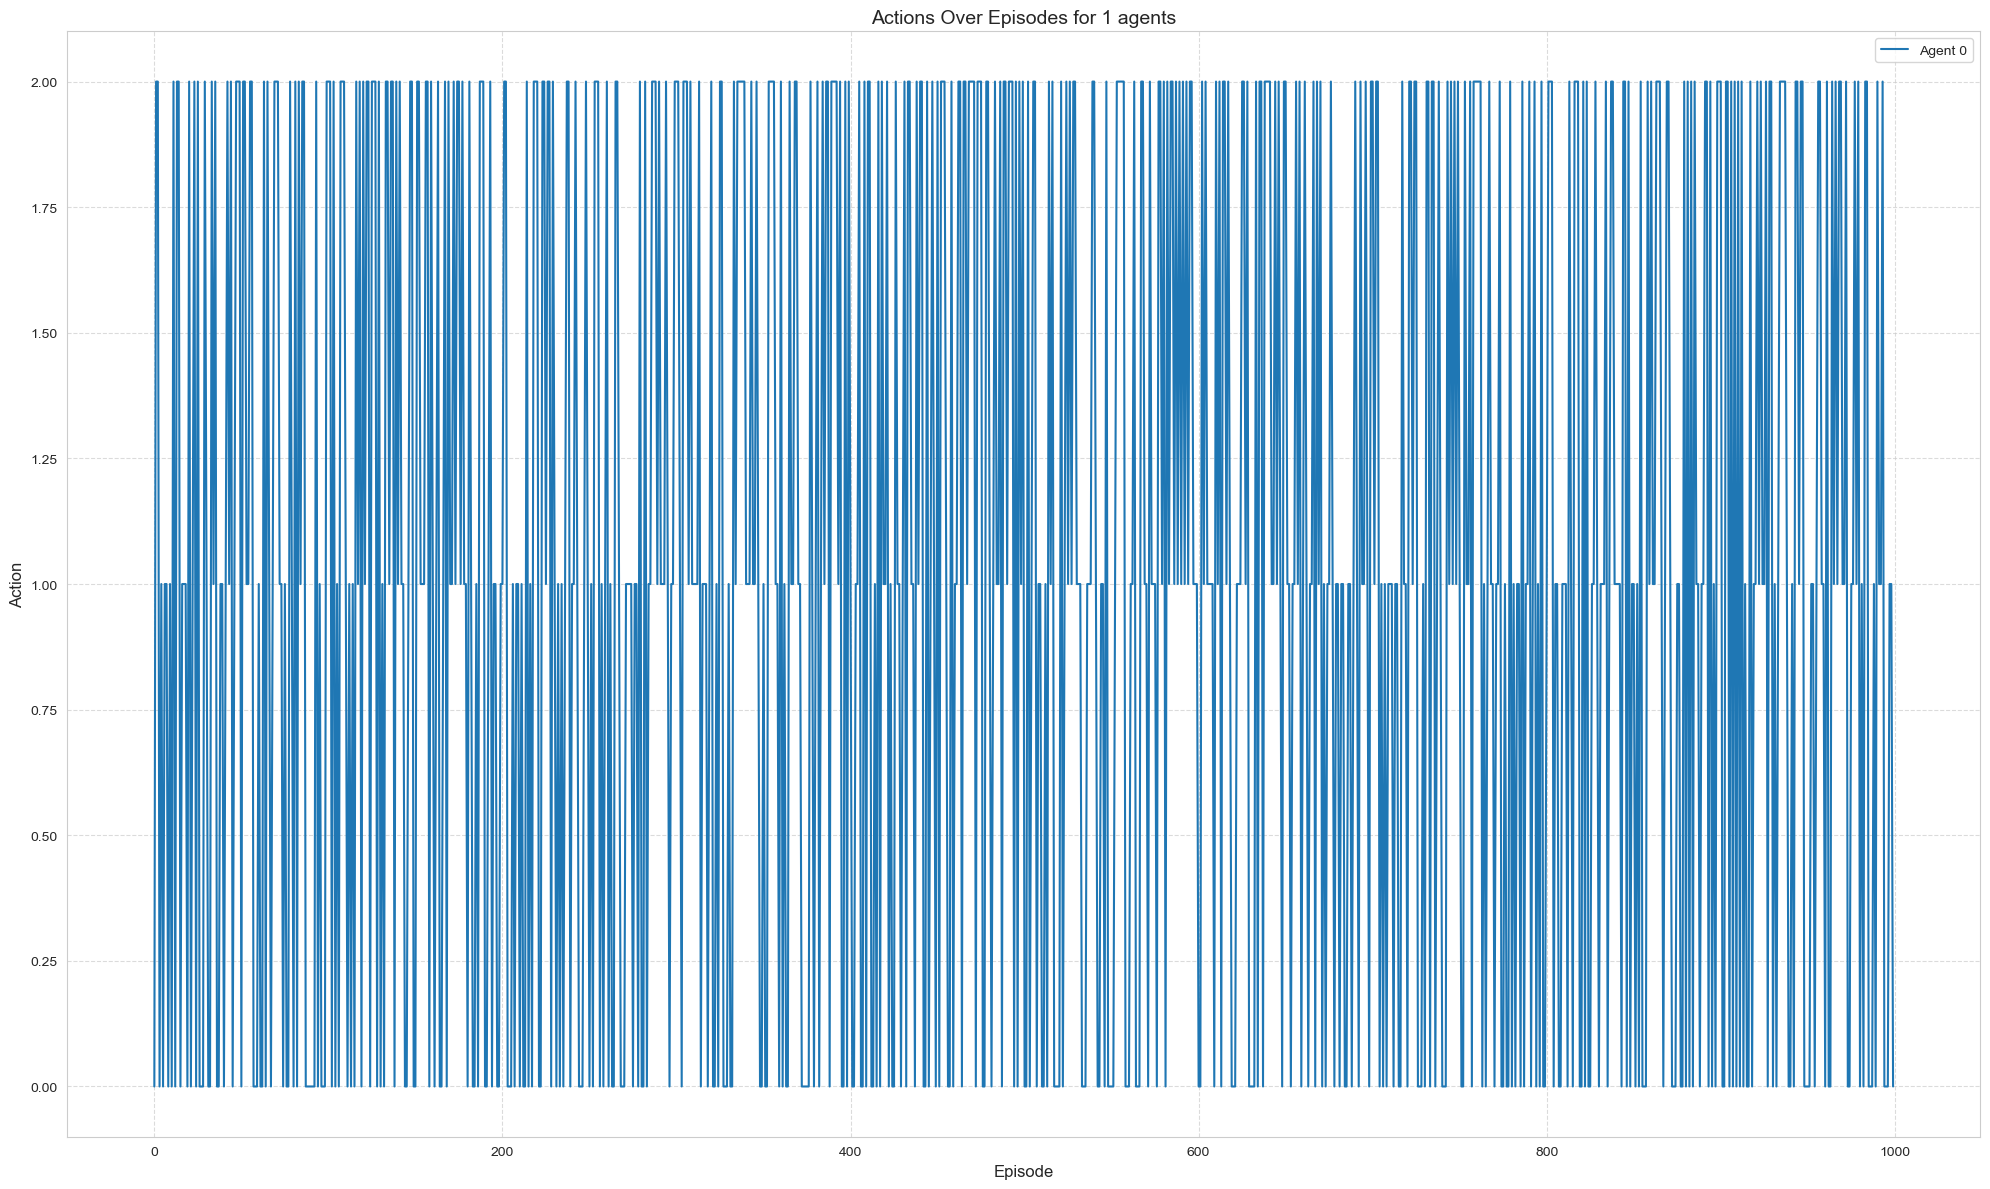

In [21]:
env.close()

**Thought:** Maybe DQN converges so fast and to a higher value compared to PPO, because based on the PPO [paper](https://arxiv.org/pdf/1707.06347.pdf): "DQN works well on game environments like the Arcade Learning Environment with discrete action spaces, it has not been demonstrated to perform well on continuous control benchmarks such as those in OpenAI Gym".

In parallel, in the PPO paper, experiments were implemented on the 49 Arcade Learning Environments between PPO, A2C and ACER algorithms. The outcome of this experiment is that PPO algorithm outperforms the other algorithms in the case that favors final performance and performs worse in the case that favors fast learning. So, I could try train PPO on more episodes?

Also, it should be noted that all the experiments in the PPO paper are implemented on environments with continuous action spaces.

### A2C

In [16]:
model = A2C("MlpPolicy", env, verbose=1)

Using cpu device


In [17]:
model.learn(total_timesteps=1000)

------------------------------------
| time/                 |          |
|    fps                | 2        |
|    iterations         | 100      |
|    time_elapsed       | 183      |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -0.371   |
|    explained_variance | -6.02    |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | -0.0195  |
|    value_loss         | 0.000621 |
------------------------------------
-------------------------------------
| time/                 |           |
|    fps                | 2         |
|    iterations         | 200       |
|    time_elapsed       | 361       |
|    total_timesteps    | 1000      |
| train/                |           |
|    entropy_loss       | -0.143    |
|    explained_variance | nan       |
|    learning_rate      | 0.0007    |
|    n_updates          | 199       |
|    policy_loss        | -0.000388 |
|    value_loss         | 

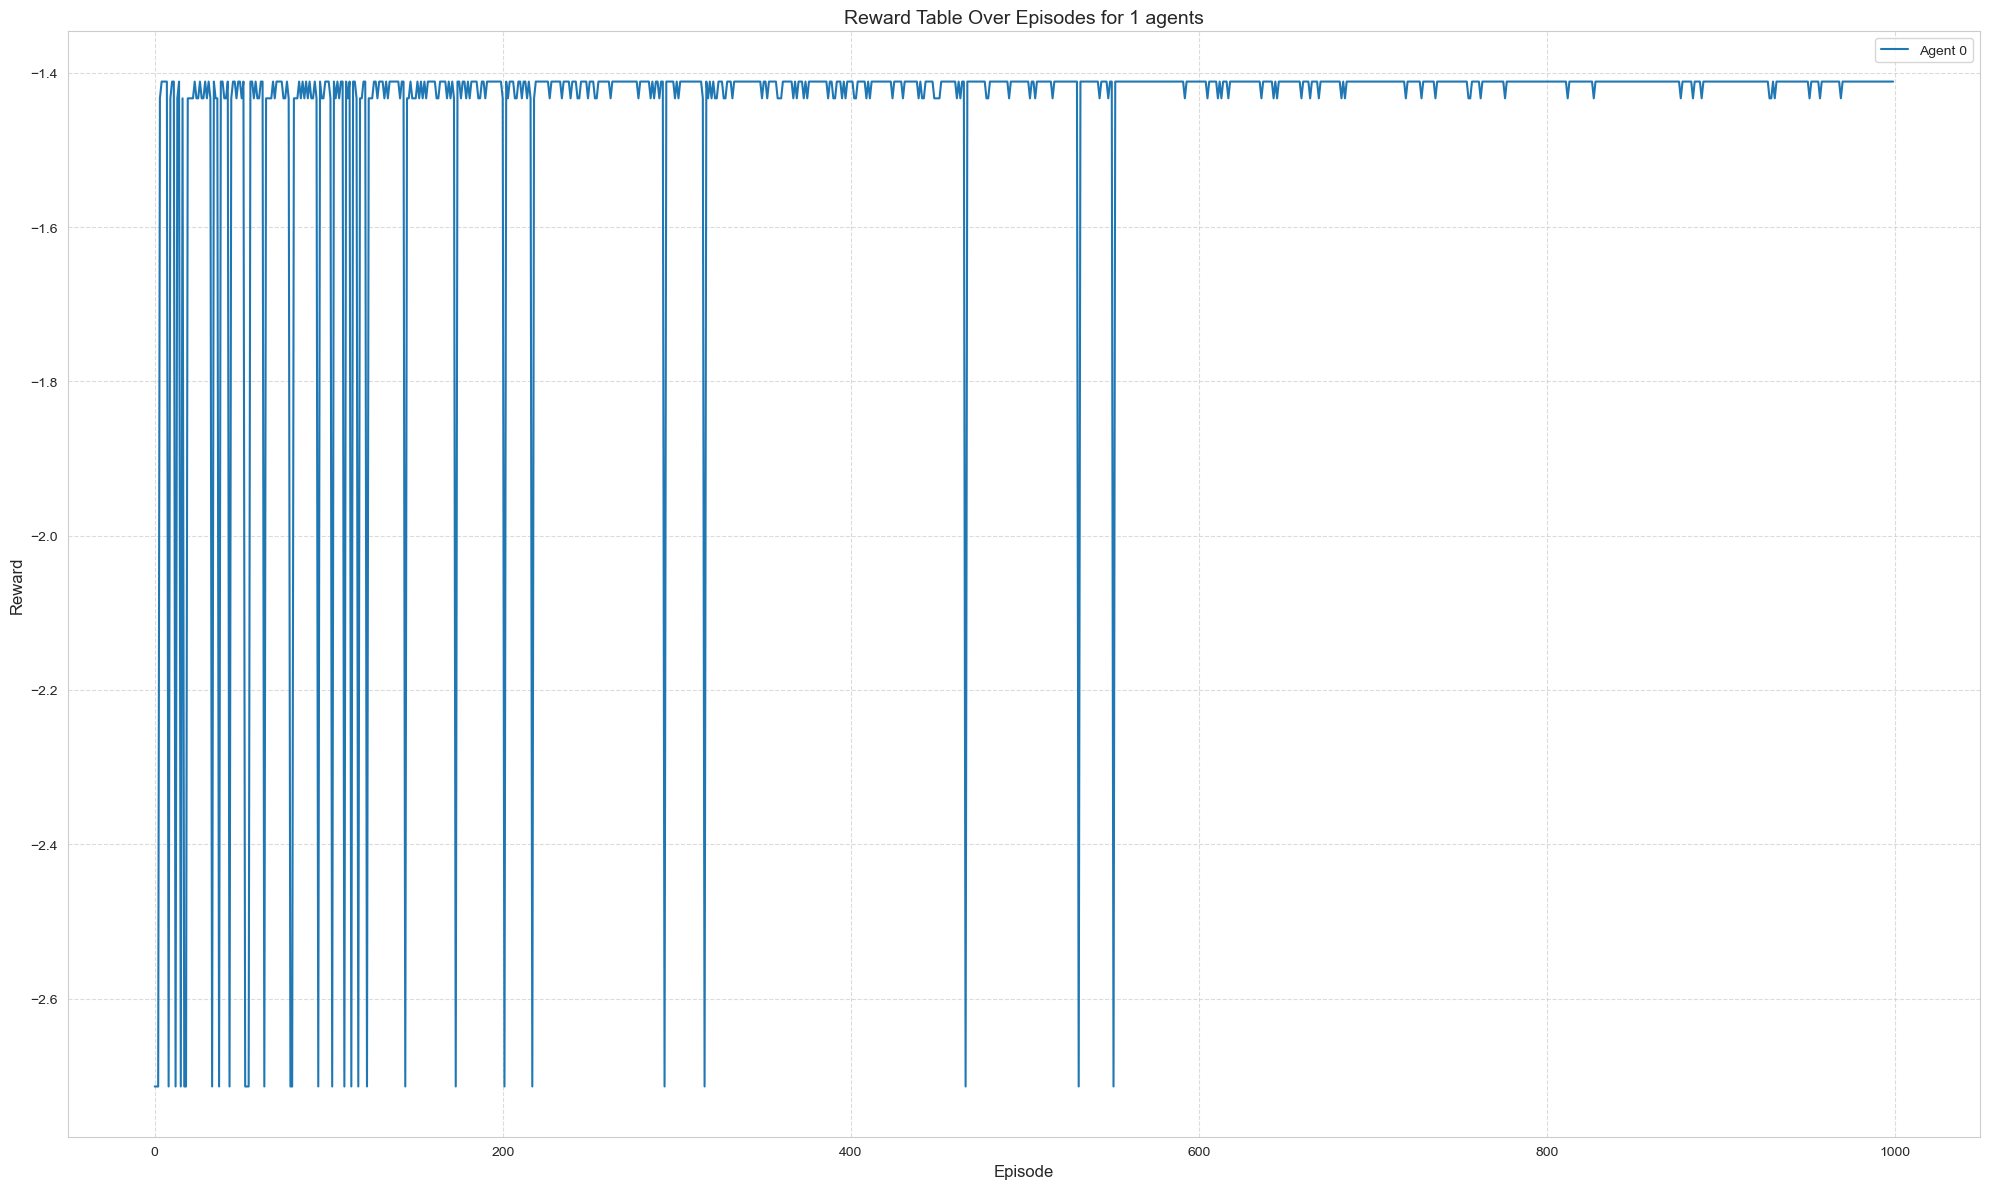

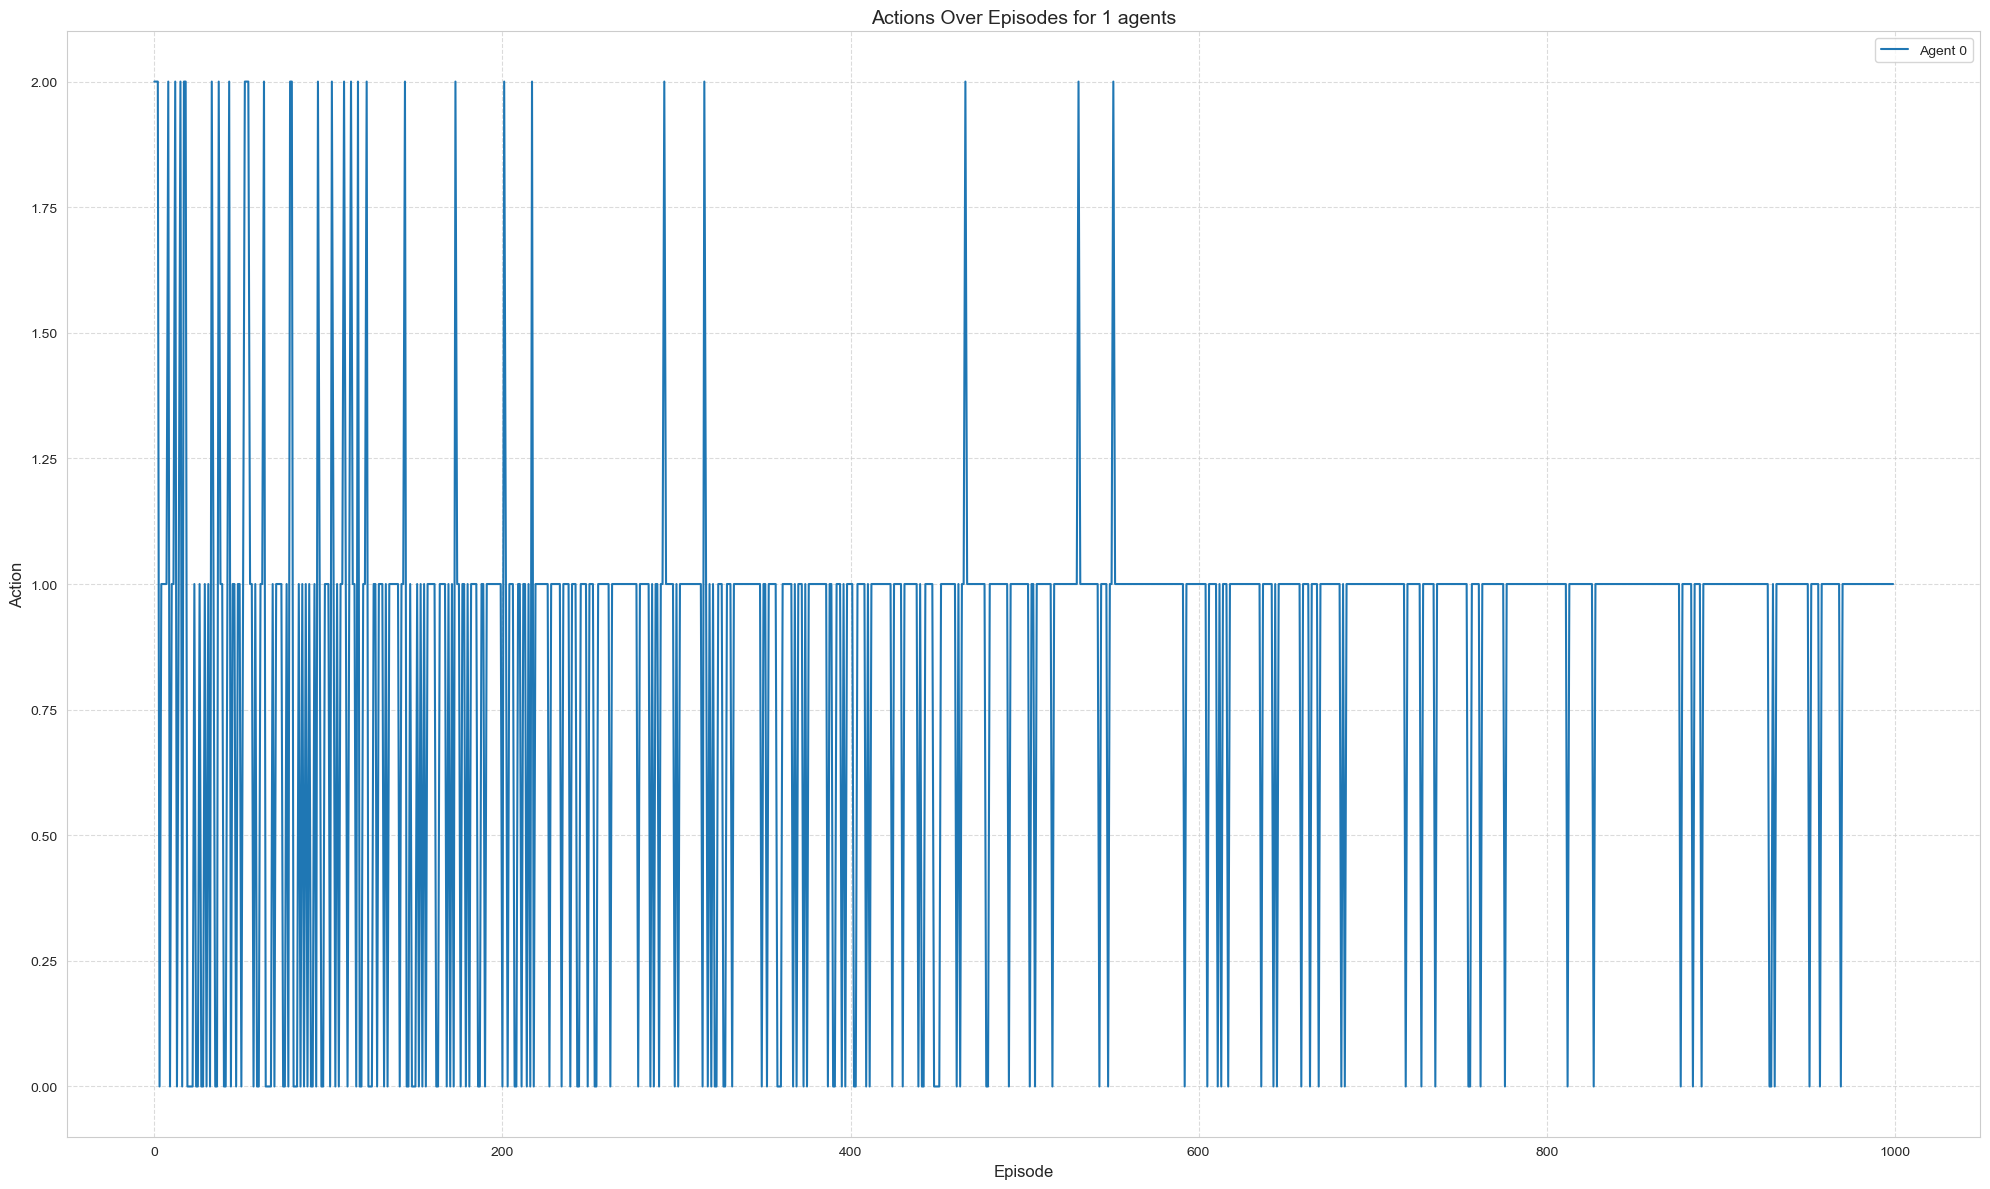

In [18]:
env.close()

In [ ]:
Sumo_sim.Sumo_stop()

# Results

> In our experiment comparing the DQN, PPO, and A2C algorithms with 600 agents, we observed intriguing performance dynamics. Surprisingly, the DQN algorithm outperformed the others, converging in just 200 episodes, while both PPO and A2C required over 1000 episodes to reach convergence. Notably, the A2C algorithm demonstrated greater stability throughout its training compared to the PPO algorithm, which exhibited occasional spikes in performance.

# Summary

> In summary, our findings deviated from our initial expectations. DQN emerged as the top-performing algorithm among the ones tested. Meanwhile, both PPO and A2C exhibited comparable outcomes in terms of convergence values and time required to converge. Notably, A2C demonstrated greater stability compared to PPO.

## Bibliography

```{bibliography}:style: unsrt

- Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). Proximal Policy Optimization Algorithms. arXiv preprint arXiv:1707.06347.